In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [22]:
df = pd.read_csv('../../../data/SCDs(AllMeasurements) (1).csv')

In [33]:
df

,Stop,LongD,LongM,LongS,LatD,LatM,LatS,LatDD,LongDD,Res 1,...,Unnamed: 22,Unnamed: 23,H2Avg,H2Max,H2Med,SCD?,std,mean,cv,log_mean
0,14,3.0,24.0,46.0,51.0,10.0,55.0,51.181944,-3.412778,3.0,...,NaN,NaN,3.00,3.0,3.0,No,0.000000,3.00,0.000000,0.477121
1,15,3.0,24.0,21.0,51.0,10.0,54.0,51.181667,-3.405833,5.0,...,NaN,NaN,28.50,46.0,31.5,No,18.770544,28.50,0.658616,1.454845
2,16,3.0,23.0,18.0,51.0,10.0,42.0,51.178333,-3.388333,2.0,...,NaN,NaN,11.25,40.0,2.0,No,19.172463,11.25,1.704219,1.051153
3,17,3.0,22.0,57.0,51.0,10.0,57.0,51.182500,-3.382500,4.0,...,NaN,NaN,7.75,13.0,7.0,No,4.112988,7.75,0.530708,0.889302
4,18,3.0,22.0,44.0,51.0,11.0,1.0,51.183611,-3.378889,1.0,...,NaN,NaN,1.75,3.0,1.5,No,0.957427,1.75,0.547101,0.243038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
res_cols = ['Res 1', 'Res 2', 'Res 3 ', 'Res 4', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22', 'Unnamed: 23']

In [24]:
df['std'] = df[res_cols].std()

In [28]:
df['std'] = df[res_cols].std(axis=1)
df['mean'] = df[res_cols].mean(axis=1)
df['cv'] = df['std'] / df['mean']

df['log_mean'] = np.log10(df['mean'])

Yes: n=18, median=17.000, mean=25.000
No:  n=63, median=7.000, mean=11.714

Mann-Whitney U: U=772.5, p=0.0196
Welch's t-test: t=2.195, p=0.0408


/var/folders/fx/yls4l5xd4cdgs4b7gy2xpdv40000gn/T/ipykernel_28493/898284026.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_vals, yes_vals], labels=['No', 'Yes'])


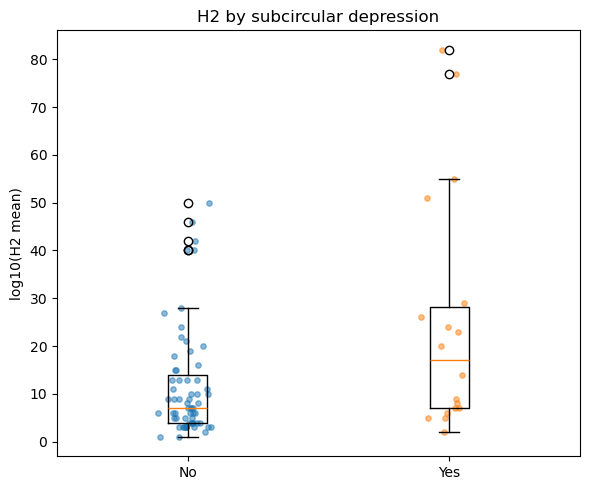

In [47]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

yes_vals = df.loc[df['SCD?'] == 'Yes', 'H2Max']
no_vals = df.loc[df['SCD?'] == 'No', 'H2Max']

no_vals = no_vals[no_vals < 100]
print(f"Yes: n={len(yes_vals)}, median={yes_vals.median():.3f}, mean={yes_vals.mean():.3f}")
print(f"No:  n={len(no_vals)}, median={no_vals.median():.3f}, mean={no_vals.mean():.3f}")

u_stat, u_p = stats.mannwhitneyu(yes_vals, no_vals, alternative='two-sided')
t_stat, t_p = stats.ttest_ind(yes_vals, no_vals, equal_var=False)

print(f"\nMann-Whitney U: U={u_stat:.1f}, p={u_p:.4f}")
print(f"Welch's t-test: t={t_stat:.3f}, p={t_p:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([no_vals, yes_vals], labels=['No', 'Yes'])
ax.scatter(np.random.normal(1, 0.04, len(no_vals)), no_vals, alpha=0.5, s=15)
ax.scatter(np.random.normal(2, 0.04, len(yes_vals)), yes_vals, alpha=0.5, s=15)
ax.set_ylabel('log10(H2 mean)')
ax.set_title('H2 by subcircular depression')
plt.tight_layout()
plt.show()

In [30]:
from scipy import stats

u_stat, _ = stats.mannwhitneyu(yes_vals, no_vals, alternative='two-sided')
n1, n2 = len(yes_vals), len(no_vals)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation: {rank_biserial:.3f}")

# back-transformed medians, actual units
print(f"Yes median (actual): {10**yes_vals.median():.2f}")
print(f"No median (actual):  {10**no_vals.median():.2f}")

Rank-biserial correlation: -0.156
Yes median (actual): 6.24
No median (actual):  4.50


In [37]:
site_id_col = 'Stop'  # swap for your actual column name

outlier_site = df.loc[df['log_mean'].idxmax(), site_id_col]
print(f"Excluding site: {outlier_site}, log_mean={df['log_mean'].max():.3f}")

df_trimmed = df[df['log_mean'] != df['log_mean'].max()].copy()

yes_t = df_trimmed.loc[df_trimmed['SCD?'] == 'Yes', 'log_mean']
no_t  = df_trimmed.loc[df_trimmed['SCD?'] == 'No', 'log_mean']

print(f"Yes: n={len(yes_t)}, median={yes_t.median():.3f}")
print(f"No:  n={len(no_t)}, median={no_t.median():.3f}")

u_stat, u_p = stats.mannwhitneyu(yes_t, no_t, alternative='two-sided')
rank_biserial = 1 - (2 * u_stat) / (len(yes_t) * len(no_t))
print(f"Mann-Whitney U: U={u_stat:.1f}, p={u_p:.4f}")
print(f"Rank-biserial: {rank_biserial:.3f}")

Excluding site: 48, log_mean=2.154
Yes: n=18, median=0.795
No:  n=63, median=0.653
Mann-Whitney U: U=666.0, p=0.2628
Rank-biserial: -0.175


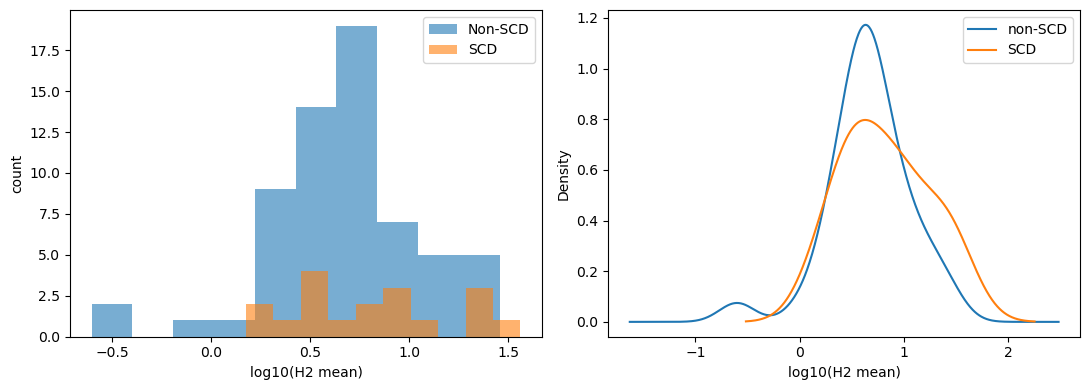

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(no_t, bins=10, alpha=0.6, label='Non-SCD')
ax[0].hist(yes_t, bins=10, alpha=0.6, label='SCD')
ax[0].set_xlabel('log10(H2 mean)')
ax[0].set_ylabel('count')
ax[0].legend()

no_t.plot(kind='kde', ax=ax[1], label='non-SCD')
yes_t.plot(kind='kde', ax=ax[1], label='SCD')
ax[1].set_xlabel('log10(H2 mean)')
ax[1].legend()

plt.tight_layout()
plt.show()